# Module 04A — Hurst Research

Research-only notebook. It may use future convergence labels because it is restricted to the training sample.

Goal: confirm the in-sample finding that Hurst dynamics, especially falling Hurst slope, relate to subsequent convergence within 1HL, 2HL, and 3HL.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.Hurst_research import build_research_features, add_future_convergence_labels, make_research_event_table, summarize_research_states

In [4]:
eligible_pairs = pd.read_parquet("data/processed/selected_pairs.parquet")
with open("data/processed/spreads.pkl", "rb") as f:
    training_spreads = pickle.load(f)

eligible_pairs.head()

,pair,dependent,independent,mean,std,min spread,max spread,theta,half_life,expected_convergence,...,stock1_has_options,stock2_has_options,stock1_num_expirations,stock2_num_expirations,stock1_first_expiration,stock2_first_expiration,stock1_last_expiration,stock2_last_expiration,eligible,exclusion_reason
0,V-MA,V,MA,-4.110665e-15,0.024864,-0.067772,0.081673,0.039095,17.729867,53.189602,...,True,True,18,16,2026-08-21,2026-08-21,2028-12-15,2028-12-15,True,None
1,MLM-VMC,MLM,VMC,1.383114e-14,0.049987,-0.182892,0.273007,0.038179,18.155329,54.465986,...,True,True,6,4,2026-08-21,2026-08-21,2027-12-17,2027-02-19,True,None
2,HLT-AXP,HLT,AXP,-2.222718e-15,0.068528,-0.268255,0.190885,0.035402,19.579342,58.738026,...,True,True,12,17,2026-08-21,2026-08-21,2028-01-21,2028-12-15,True,None
3,SHW-HD,SHW,HD,-1.124588e-14,0.056705,-0.156361,0.178546,0.034308,20.203513,60.610538,...,True,True,7,17,2026-08-21,2026-08-21,2028-01-21,2028-12-15,True,None
4,URI-MS,URI,MS,-4.401002e-15,0.087648,-0.277321,0.274505,0.033124,20.925609,62.776828,...,True,True,12,16,2026-08-21,2026-08-21,2028-01-21,2028-12-15,True,None


In [5]:
HURST_WINDOW = 120
HURST_MIN_LAG = 2
HURST_MAX_LAG = 40
EMA_SPAN = 10
DYNAMICS_WINDOW = 10
Z_WINDOW = 120
MIN_ABS_Z = 0.5

In [6]:
row = eligible_pairs.iloc[0]
pair = row["pair"]
dep = row["dependent"]
indep = row["independent"]
half_life = float(row["half_life"])
spread = training_spreads[(dep, indep)]

features = build_research_features(spread, HURST_WINDOW, HURST_MIN_LAG, HURST_MAX_LAG, EMA_SPAN, DYNAMICS_WINDOW, Z_WINDOW)
features.tail()

,spread,zscore,hurst,hurst_smooth,hurst_slope,hurst_acceleration
Date,,,,,,
2022-12-20,-0.020713,-1.205623,0.214350,0.193351,0.004705,0.000708
2022-12-21,-0.019956,-1.128561,0.220811,0.198344,0.005298,0.000675
2022-12-22,-0.018877,-1.029267,0.224386,0.203079,0.005803,0.000647
2022-12-23,-0.019921,-1.091026,0.227341,0.207490,0.006012,0.000578
2022-12-27,-0.023546,-1.344071,0.232052,0.211956,0.005850,0.000444


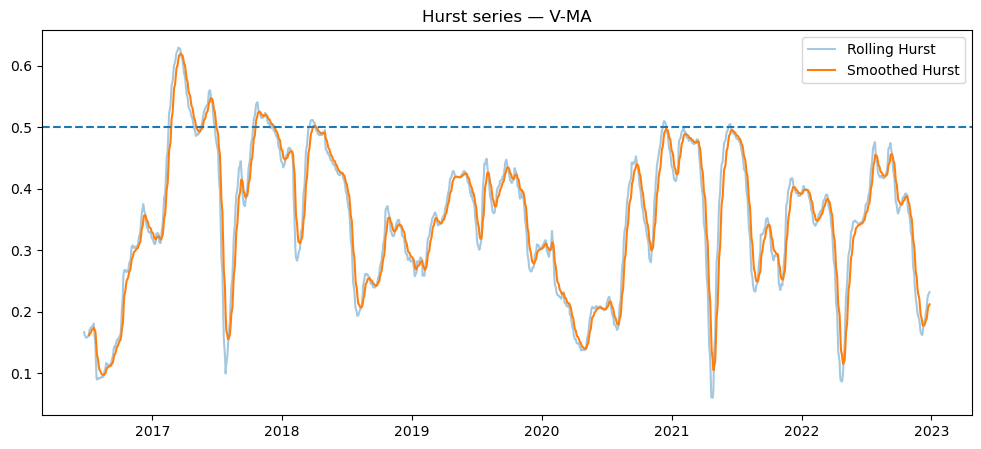

In [7]:
plt.figure(figsize=(12,5))
plt.plot(features.index, features["hurst"], alpha=0.4, label="Rolling Hurst")
plt.plot(features.index, features["hurst_smooth"], label="Smoothed Hurst")
plt.axhline(0.5, linestyle="--")
plt.title(f"Hurst series — {pair}")
plt.legend()
plt.show()

In [12]:
research_frames=[]
for _, row in eligible_pairs.iterrows():
    pair=row["pair"]; dep=row["dependent"]; indep=row["independent"]; half_life=float(row["half_life"])
    key=(dep,indep)
    if key not in training_spreads: continue
    f=build_research_features(training_spreads[key], HURST_WINDOW,HURST_MIN_LAG,HURST_MAX_LAG,EMA_SPAN,DYNAMICS_WINDOW,Z_WINDOW)
    f=add_future_convergence_labels(f, half_life, horizons=(1.0,2.0,3.0))
    events = make_research_event_table(f,pair,half_life,MIN_ABS_Z)
    events = events.reset_index()

# Rename whatever the first column is to "date"
    events = events.rename(
        columns={
            events.columns[0]: "date"
        }
    )

    research_frames.append(events)

event_data=pd.concat(research_frames,ignore_index=True).sort_values(["date","pair"]).reset_index(drop=True)
# ============================================================
# CORRECT VERSION
# ============================================================

test_data = event_data.copy()

# Sort full time series first
test_data = test_data.sort_values(
    ["pair", "date"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Previous Hurst slope by pair
# ------------------------------------------------------------

test_data["previous_hurst_slope"] = (
    test_data
    .groupby("pair")["hurst_slope"]
    .shift(1)
)


# ------------------------------------------------------------
# Hurst conditions
# ------------------------------------------------------------

test_data["hurst_falling"] = (
    test_data["hurst_slope"] < 0
)

test_data["hurst_negative_cross"] = (
    (test_data["previous_hurst_slope"] >= 0)
    &
    (test_data["hurst_slope"] < 0)
)


# ------------------------------------------------------------
# NOW restrict to 1.5 <= |Z| < 2
# ------------------------------------------------------------

test_data = test_data[
    (test_data["abs_z"] >= 1.5)
    &
    (test_data["abs_z"] < 2.0)
].copy()


# ------------------------------------------------------------
# Summary helper
# ------------------------------------------------------------

def summarize_condition(
    data,
    condition,
    label
):

    sample = data.loc[
        condition
    ].copy()

    return {

        "condition":
            label,

        "observations":
            len(sample),

        "convergence_rate_1hl":
            sample[
                "converged_1hl"
            ].mean(),

        "convergence_rate_2hl":
            sample[
                "converged_2hl"
            ].mean(),

        "convergence_rate_3hl":
            sample[
                "converged_3hl"
            ].mean(),

        "median_days_to_convergence":
            sample[
                "days_to_convergence_3hl"
            ].median(),

        "mean_max_adverse_excursion":
            sample[
                "max_adverse_excursion_3hl"
            ].mean(),

        "mean_abs_z":
            sample[
                "abs_z"
            ].mean(),

        "mean_hurst":
            sample[
                "hurst_smooth"
            ].mean(),

        "mean_hurst_slope":
            sample[
                "hurst_slope"
            ].mean()

    }


# ------------------------------------------------------------
# Build comparison
# ------------------------------------------------------------

results = []

results.append(
    summarize_condition(
        test_data,
        pd.Series(
            True,
            index=test_data.index
        ),
        "No Hurst filter"
    )
)

results.append(
    summarize_condition(
        test_data,
        test_data[
            "hurst_falling"
        ],
        "Hurst slope < 0"
    )
)

results.append(
    summarize_condition(
        test_data,
        test_data[
            "hurst_negative_cross"
        ],
        "Hurst slope crosses below 0"
    )
)


comparison = pd.DataFrame(
    results
)

comparison
state_summary=summarize_research_states(event_data)
state_summary

,hurst_state,observations,mean_abs_z,convergence_rate_1hl,convergence_rate_2hl,convergence_rate_3hl,median_days_to_convergence,mean_max_adverse_excursion
0,falling_accelerating,8152,1.285631,0.481722,0.726938,0.859789,21.0,0.967861
1,falling_decelerating,3790,1.348107,0.464380,0.714776,0.877836,22.0,0.956597
2,rising_accelerating,7584,1.392494,0.482199,0.713608,0.846783,20.0,0.899792
3,rising_decelerating,4354,1.326989,0.452917,0.693615,0.829812,21.0,0.820665


In [13]:
analysis=event_data.dropna(subset=["hurst_slope"]).copy()
analysis["z_bucket"]=pd.cut(analysis["abs_z"], bins=[0.5,1.0,1.5,2.0,3.0,np.inf], labels=["0.5–1","1–1.5","1.5–2","2–3","3+"], right=False)
result=(analysis.groupby(["z_bucket","hurst_falling"],observed=True).agg(observations=("pair","size"), convergence_rate_2hl=("converged_2hl","mean"), median_days_to_convergence=("days_to_convergence_3hl","median")).reset_index())
result

,z_bucket,hurst_falling,observations,convergence_rate_2hl,median_days_to_convergence
0,0.5–1,False,4128,0.801599,13.0
1,0.5–1,True,4284,0.806489,13.0
2,1–1.5,False,3468,0.712803,22.0
3,1–1.5,True,3861,0.717690,23.0
4,1.5–2,False,2344,0.626706,27.0
5,1.5–2,True,2375,0.660211,28.0
6,2–3,False,1776,0.604730,29.0
7,2–3,True,1249,0.590873,30.0
8,3+,False,222,0.486486,34.0
9,3+,True,173,0.595376,31.0


In [14]:
event_data.to_parquet("data/processed/hurst_research_events.parquet",index=False)
state_summary.to_parquet("data/processed/hurst_research_summary.parquet",index=False)
print("Research outputs saved.")

Research outputs saved.
